# Initiation à l'API Berserk

L'objectif de ce notebook est de comprendre comment utiliser l'API Berserk.

## 1. Imports de libraries

In [1]:
from dotenv import load_dotenv

import os
import sys
sys.path.append(os.path.abspath(".."))

from pprint import pprint

import berserk
import pandas as pd 

## 2. Chargement du token

In [2]:
load_dotenv("../.env")

token = os.getenv("LICHESS_API_TOKEN")

if not token:
    raise ValueError("LICHESS_API_TOKEN introuvable dans le fichier .env")

print("Token chargé avec succès")

Token chargé avec succès


## 3. Connexion à l'API Berserk

In [3]:
session = berserk.TokenSession(token)
client = berserk.Client(session=session)

print("Client Berserk créé avec succès")

Client Berserk créé avec succès


## 4. Affichage des informations de mon profil Lichess

In [4]:
account = client.account.get()
pprint(account)

{'blocking': False,
 'count': {'all': 1,
           'bookmark': 0,
           'draw': 0,
           'import': 0,
           'loss': 0,
           'me': 0,
           'playing': 0,
           'rated': 1,
           'win': 1},
 'createdAt': datetime.datetime(2026, 3, 17, 18, 3, 37, 330000, tzinfo=datetime.timezone.utc),
 'followable': True,
 'following': False,
 'id': 'raydennnnnnnnn',
 'perfs': {'blitz': {'games': 1,
                     'prog': 0,
                     'prov': True,
                     'rating': 1674,
                     'rd': 297},
           'bullet': {'games': 0,
                      'prog': 0,
                      'prov': True,
                      'rating': 1500,
                      'rd': 500},
           'classical': {'games': 0,
                         'prog': 0,
                         'prov': True,
                         'rating': 1500,
                         'rd': 500},
           'correspondence': {'games': 0,
                              'prog'

## 5. Importation des parties d'un joueur

Dans cet exemple, il est importé les parties du joueur Chesstam. Un maximim de 5 parties sont importées. Seules des parties jouées en mode rapide sont considérées.

In [5]:
import datetime

username = "chesstam"

start = berserk.utils.to_millis(datetime.datetime(2018, 12, 8))
end = berserk.utils.to_millis(datetime.datetime(2018, 12, 9))

games = client.games.export_by_player(
    username,
    max=150,
    since="start",
    until="end",
    perf_type="rapid",
    opening=True,
)

games = list(games)



print(f"{len(games)} parties récupérées")

150 parties récupérées


## 6. Inspection d'une partie

Cette première commande permet d'extraire toutes les informations d'une partie. L'API a converti le format PGN en JSON.

In [6]:
pprint(games[0])



{'clock': {'increment': 0, 'initial': 600, 'totalTime': 600},
 'createdAt': datetime.datetime(2026, 3, 24, 22, 57, 44, 39000, tzinfo=datetime.timezone.utc),
 'id': 'IwUuTLuK',
 'lastMoveAt': datetime.datetime(2026, 3, 24, 23, 9, 13, 820000, tzinfo=datetime.timezone.utc),
 'moves': 'd4 d6 d5 Nf6 Nc3 g6 e4 Bg7 h3 Nbd7 Bb5 O-O Nf3 a6 Bxd7 Bxd7 e5 dxe5 '
          'Nxe5 Re8 O-O Bf5 g4 Bc8 f4 c5 f5 gxf5 gxf5 Qb6 Be3 Qxb2 Rb1 Qxc3 '
          'Ng4 Nxg4 hxg4 Qxe3+ Rf2 Be5 Kf1 Qh3+ Ke2 Qxg4+ Rf3 Qe4+ Kf2 Bd4+ '
          'Kg2 Bxf5 Kf1 Kh8 c3 Bg7 Rf2 Bh3+ Kg1 Bxc3 Rxf7 Qg6+ Kh2 Qg2#',
 'opening': {'eco': 'A41', 'name': "Queen's Pawn Game", 'ply': 2},
 'perf': 'rapid',
 'players': {'black': {'rating': 1430,
                       'ratingDiff': 6,
                       'user': {'id': 'mavie02', 'name': 'mavie02'}},
             'white': {'rating': 1431,
                       'ratingDiff': -6,
                       'user': {'id': 'chesstam', 'name': 'Chesstam'}}},
 'rated': True,
 'source': 'po

Cette seconde commande permet d'extraire les différents champs d'une partie.

In [7]:
print(sorted(games[0].keys()))

for key in sorted(games[0].keys()):
    print(key)

['clock', 'createdAt', 'id', 'lastMoveAt', 'moves', 'opening', 'perf', 'players', 'rated', 'source', 'speed', 'status', 'variant', 'winner']
clock
createdAt
id
lastMoveAt
moves
opening
perf
players
rated
source
speed
status
variant
winner


Les prochaines commandes permettent d'afficher les sous-champs des champs "players" et "opening".

In [8]:
for key in sorted(games[0]["players"].keys()):
    print(key)

print("\n")

for key in sorted(games[0]["players"]["white"].keys()):
    print(key)

print("\n")

for key in sorted(games[0]["players"]["white"]["user"].keys()):
    print(key)

print("\n")

black
white


rating
ratingDiff
user


id
name




In [9]:
for key in sorted(games[0]["opening"].keys()):
    print(key)

eco
name
ply


# 7. Applatissement d'une partie

La commande suivante éxécute une fonction permettant de convertir una partie brute en une structure plate.

In [10]:
from src.ingestion.flatten_games import flatten_game



flat = flatten_game(games[0])
flat

{'game_id': 'IwUuTLuK',
 'datetime_utc': datetime.datetime(2026, 3, 24, 22, 57, 44, 39000, tzinfo=datetime.timezone.utc),
 'perf': 'rapid',
 'speed': 'rapid',
 'rated': True,
 'source': 'pool',
 'status': 'mate',
 'winner': 'black',
 'white_id': 'chesstam',
 'white_name': 'Chesstam',
 'black_id': 'mavie02',
 'black_name': 'mavie02',
 'white_rating_before': 1431,
 'black_rating_before': 1430,
 'white_rating_diff': -6,
 'black_rating_diff': 6,
 'white_rating_after': 1425,
 'black_rating_after': 1436,
 'opening_eco': 'A41',
 'opening_name': "Queen's Pawn Game",
 'clock_initial': 600,
 'clock_increment': 0,
 'has_increment': 0,
 'moves': 'd4 d6 d5 Nf6 Nc3 g6 e4 Bg7 h3 Nbd7 Bb5 O-O Nf3 a6 Bxd7 Bxd7 e5 dxe5 Nxe5 Re8 O-O Bf5 g4 Bc8 f4 c5 f5 gxf5 gxf5 Qb6 Be3 Qxb2 Rb1 Qxc3 Ng4 Nxg4 hxg4 Qxe3+ Rf2 Be5 Kf1 Qh3+ Ke2 Qxg4+ Rf3 Qe4+ Kf2 Bd4+ Kg2 Bxf5 Kf1 Kh8 c3 Bg7 Rf2 Bh3+ Kg1 Bxc3 Rxf7 Qg6+ Kh2 Qg2#',
 'ply_count': 62}

# 8. Conversion en une partie du point de vue du joueur

La commande suivante fait appel à une fonction permettant de transformer une partie aplatie en 2 rangées (1 par joueur).

In [11]:
from src.ingestion.player_view import game_to_player_rows

flat = flatten_game(games[1])
rows = game_to_player_rows(flat)

rows

[{'game_id': 'ri4Z71sM',
  'datetime_utc': datetime.datetime(2026, 3, 24, 22, 54, 14, 213000, tzinfo=datetime.timezone.utc),
  'weekday': 1,
  'player_id': 'kurt_62',
  'player_name': 'Kurt_62',
  'opponent_id': 'chesstam',
  'opponent_name': 'Chesstam',
  'color_player': 'white',
  'result_player': 0.0,
  'elo_player_before': 1374,
  'elo_player_after': 1369,
  'elo_diff_player': -5,
  'termination_type': 'mate',
  'has_increment': 0,
  'opening_family': "Queen's Pawn Game",
  'opening_eco': 'D00',
  'opening_name': "Queen's Pawn Game",
  'ply_count': 32,
  'perf': 'rapid',
  'speed': 'rapid',
  'rated': True,
  'source': 'pool'},
 {'game_id': 'ri4Z71sM',
  'datetime_utc': datetime.datetime(2026, 3, 24, 22, 54, 14, 213000, tzinfo=datetime.timezone.utc),
  'weekday': 1,
  'player_id': 'chesstam',
  'player_name': 'Chesstam',
  'opponent_id': 'kurt_62',
  'opponent_name': 'Kurt_62',
  'color_player': 'black',
  'result_player': 1.0,
  'elo_player_before': 1426,
  'elo_player_after': 143

# 9. Table complète des parties du joueur

La commande suivante permet de convertir un ensemble de parties brutes en un ensemble de parties aplaties en 2 rangées (format de la section précédente).

In [12]:
from src.ingestion.build_player_games import build_player_games

df_player_games = build_player_games(games)

df_player_games = df_player_games[df_player_games["player_id"] == username].reset_index(drop=True)

print(len(games))

print(len(df_player_games))

print(df_player_games.columns)

df_player_games.head(150)

150
150
Index(['game_id', 'datetime_utc', 'weekday', 'player_id', 'player_name',
       'opponent_id', 'opponent_name', 'color_player', 'result_player',
       'elo_player_before', 'elo_player_after', 'elo_diff_player',
       'termination_type', 'has_increment', 'opening_family', 'opening_eco',
       'opening_name', 'ply_count', 'perf', 'speed', 'rated', 'source'],
      dtype='str')


,game_id,datetime_utc,weekday,player_id,player_name,opponent_id,opponent_name,color_player,result_player,elo_player_before,...,termination_type,has_increment,opening_family,opening_eco,opening_name,ply_count,perf,speed,rated,source
0,IwUuTLuK,2026-03-24 22:57:44.039000+00:00,1,chesstam,Chesstam,mavie02,mavie02,white,0.0,1431,...,mate,0,Queen's Pawn Game,A41,Queen's Pawn Game,62,rapid,rapid,True,pool
1,ri4Z71sM,2026-03-24 22:54:14.213000+00:00,1,chesstam,Chesstam,kurt_62,Kurt_62,black,1.0,1426,...,mate,0,Queen's Pawn Game,D00,Queen's Pawn Game,32,rapid,rapid,True,pool
2,oCB4t8YQ,2026-03-24 22:47:35.833000+00:00,1,chesstam,Chesstam,visitor756,visitor756,white,0.0,1431,...,resign,0,Rapport-Jobava System,D01,Rapport-Jobava System,58,rapid,rapid,True,pool
3,6Y7DjsJz,2026-03-24 22:43:59.300000+00:00,1,chesstam,Chesstam,ms1991,MS1991,black,0.0,1437,...,resign,0,Queen's Gambit Declined,D06,Queen's Gambit Declined: Marshall Defense,47,rapid,rapid,True,pool
4,IEIm1oph,2026-03-24 22:28:49.648000+00:00,1,chesstam,Chesstam,blehblehblehx,blehblehblehx,black,0.0,1442,...,mate,0,Queen's Pawn Game,D00,Queen's Pawn Game: Accelerated London System,101,rapid,rapid,True,pool
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,GQpdnhL8,2026-03-08 18:21:15.743000+00:00,6,chesstam,Chesstam,thiagonvcardoso,Thiagonvcardoso,black,0.0,1403,...,resign,0,Scandinavian Defense,B01,Scandinavian Defense: Mieses-Kotroc Variation,110,rapid,rapid,True,pool
146,ooj4uM5q,2026-03-08 18:16:21.055000+00:00,6,chesstam,Chesstam,dogo31,dogo31,white,0.0,1409,...,resign,0,English Defense,A40,English Defense,36,rapid,rapid,True,pool
147,EJI7kAmp,2026-03-08 13:32:21.006000+00:00,6,chesstam,Chesstam,jessy8888,jessy8888,black,1.0,1403,...,timeout,0,Scandinavian Defense,B01,Scandinavian Defense,58,rapid,rapid,True,pool
148,6eXfFigs,2026-03-08 13:21:33.043000+00:00,6,chesstam,Chesstam,oleksandr1961,Oleksandr1961,black,1.0,1396,...,mate,0,Scandinavian Defense,B01,Scandinavian Defense: Mieses-Kotroc Variation,54,rapid,rapid,True,pool


# 10. Implémentation des features partie "entre-parties"

In [13]:
from src.features.temporal_features import add_basic_temporal_features

df_player_games_v2 = add_basic_temporal_features(df_player_games)

df_player_games_v2[["player_id", "index", "delay_previous_game", "streak_before", "streak_after"]].head(150)


,player_id,index,delay_previous_game,streak_before,streak_after
149,chesstam,0,NaN,NaN,-1
148,chesstam,1,415.026,-1.0,1
147,chesstam,2,647.963,1.0,2
146,chesstam,3,17040.049,2.0,-1
145,chesstam,4,294.688,-1.0,-2
...,...,...,...,...,...
4,chesstam,145,1154.245,1.0,-1
3,chesstam,146,909.652,-1.0,-2
2,chesstam,147,216.533,-2.0,-3
1,chesstam,148,398.380,-3.0,1


# 11 Création des séries temporelles

## 11.1 Série temporelle session

L'expression ci-dessous fait appel à une fonction permettant d'associer chaque partie à une session.

In [14]:
from src.features.session_features import _add_sessions

df_player_games_v3 = _add_sessions(df_player_games_v2)

df_player_games_v3[["player_id", "datetime_utc", "delay_previous_game", "session_id"]].head(30)

,player_id,datetime_utc,delay_previous_game,session_id
149,chesstam,2026-03-08 13:14:38.017000+00:00,NaN,1
148,chesstam,2026-03-08 13:21:33.043000+00:00,415.026,1
147,chesstam,2026-03-08 13:32:21.006000+00:00,647.963,1
146,chesstam,2026-03-08 18:16:21.055000+00:00,17040.049,2
145,chesstam,2026-03-08 18:21:15.743000+00:00,294.688,2
144,chesstam,2026-03-08 19:13:16.081000+00:00,3120.338,2
143,chesstam,2026-03-08 19:25:55.710000+00:00,759.629,2
142,chesstam,2026-03-08 19:30:51.088000+00:00,295.378,2
141,chesstam,2026-03-08 19:44:44.569000+00:00,833.481,2
140,chesstam,2026-03-09 17:40:55.231000+00:00,78970.662,3


L'expression ci-dessous réplique le bloc précédent et intègre des features associées aux sessions.

In [15]:
from src.features.session_features import add_sessions

df_player_games_v4 = add_sessions(df_player_games_v3)

df_player_games_v4[["player_id", "session_id", "session_position", "session_size", "session_score", "datetime_utc", "session_delay", "session_discrete_delay"]].head(30)

,player_id,session_id,session_position,session_size,session_score,datetime_utc,session_delay,session_discrete_delay
149,chesstam,1,0,3,0.666667,2026-03-08 13:14:38.017000+00:00,NaN,NaN
148,chesstam,1,1,3,0.666667,2026-03-08 13:21:33.043000+00:00,NaN,NaN
147,chesstam,1,2,3,0.666667,2026-03-08 13:32:21.006000+00:00,NaN,NaN
146,chesstam,2,0,6,0.166667,2026-03-08 18:16:21.055000+00:00,17040.049,A
145,chesstam,2,1,6,0.166667,2026-03-08 18:21:15.743000+00:00,17040.049,A
144,chesstam,2,2,6,0.166667,2026-03-08 19:13:16.081000+00:00,17040.049,A
143,chesstam,2,3,6,0.166667,2026-03-08 19:25:55.710000+00:00,17040.049,A
142,chesstam,2,4,6,0.166667,2026-03-08 19:30:51.088000+00:00,17040.049,A
141,chesstam,2,5,6,0.166667,2026-03-08 19:44:44.569000+00:00,17040.049,A
140,chesstam,3,0,5,0.000000,2026-03-09 17:40:55.231000+00:00,78970.662,B


## 11.2 Série temporelle games_per_day

Même principe que pour la série sessions sauf qu'ici une session de jeu est une journée.

In [16]:
from src.features.day_features import add_day_features

df_player_games_v5 = add_day_features(df_player_games_v4)

df_player_games_v5[["player_id", "datetime_utc", "day_date_utc", "day_n_games", "day_score", "day_position"]].head(30)

,player_id,datetime_utc,day_date_utc,day_n_games,day_score,day_position
149,chesstam,2026-03-08 13:14:38.017000+00:00,2026-03-08,9,0.333333,0
148,chesstam,2026-03-08 13:21:33.043000+00:00,2026-03-08,9,0.333333,1
147,chesstam,2026-03-08 13:32:21.006000+00:00,2026-03-08,9,0.333333,2
146,chesstam,2026-03-08 18:16:21.055000+00:00,2026-03-08,9,0.333333,3
145,chesstam,2026-03-08 18:21:15.743000+00:00,2026-03-08,9,0.333333,4
144,chesstam,2026-03-08 19:13:16.081000+00:00,2026-03-08,9,0.333333,5
143,chesstam,2026-03-08 19:25:55.710000+00:00,2026-03-08,9,0.333333,6
142,chesstam,2026-03-08 19:30:51.088000+00:00,2026-03-08,9,0.333333,7
141,chesstam,2026-03-08 19:44:44.569000+00:00,2026-03-08,9,0.333333,8
140,chesstam,2026-03-09 17:40:55.231000+00:00,2026-03-09,14,0.464286,0


## 11.3 Série temporelle games_per_week

Même principe que pour la série sessions sauf qu'ici une session de jeu est une semaine.

In [17]:
from src.features.week_features import add_week_features

df_player_games_v6 = add_week_features(df_player_games_v5)

df_player_games_v6[["player_id", "datetime_utc", "week_id", "week_n_games", "week_score", "week_position", "termination_type", "result_player"]].head(30)

,player_id,datetime_utc,week_id,week_n_games,week_score,week_position,termination_type,result_player
149,chesstam,2026-03-08 13:14:38.017000+00:00,2026-W10,9,0.333333,0,resign,0.0
148,chesstam,2026-03-08 13:21:33.043000+00:00,2026-W10,9,0.333333,1,mate,1.0
147,chesstam,2026-03-08 13:32:21.006000+00:00,2026-W10,9,0.333333,2,timeout,1.0
146,chesstam,2026-03-08 18:16:21.055000+00:00,2026-W10,9,0.333333,3,resign,0.0
145,chesstam,2026-03-08 18:21:15.743000+00:00,2026-W10,9,0.333333,4,resign,0.0
144,chesstam,2026-03-08 19:13:16.081000+00:00,2026-W10,9,0.333333,5,mate,0.0
143,chesstam,2026-03-08 19:25:55.710000+00:00,2026-W10,9,0.333333,6,mate,0.0
142,chesstam,2026-03-08 19:30:51.088000+00:00,2026-W10,9,0.333333,7,mate,0.0
141,chesstam,2026-03-08 19:44:44.569000+00:00,2026-W10,9,0.333333,8,mate,1.0
140,chesstam,2026-03-09 17:40:55.231000+00:00,2026-W11,73,0.479452,0,mate,0.0


In [18]:
print(df_player_games_v6.columns)

Index(['game_id', 'datetime_utc', 'weekday', 'player_id', 'player_name',
       'opponent_id', 'opponent_name', 'color_player', 'result_player',
       'elo_player_before', 'elo_player_after', 'elo_diff_player',
       'termination_type', 'has_increment', 'opening_family', 'opening_eco',
       'opening_name', 'ply_count', 'perf', 'speed', 'rated', 'source',
       'index', 'delay_previous_game', 'streak_after', 'streak_before',
       'new_session', 'session_id', 'session_position', 'session_size',
       'session_score', 'is_session_start', 'session_delay',
       'session_discrete_delay', 'day_date_utc', 'day_n_games', 'day_score',
       'day_position', 'week_id', 'week_n_games', 'week_score',
       'week_position'],
      dtype='str')


## 11.4 Agrégation de ces catégories de features (tout en 1 fonction)

In [19]:
from src.features.game_features import build_game_features

df_player_games = build_player_games(games)

df_player_games = df_player_games[df_player_games["player_id"] == username].reset_index(drop=True)

df_player_games["player_id"].isna().sum()

games_final = build_game_features(df_player_games)

# 12. Features joueur

## 12.1 Features liées au style de jeu

In [20]:
from src.features.player_features import _init_player_features
from src.features.player_features import _add_style_features

features = _init_player_features(games_final) 
features_v1 = _add_style_features(games_final, features)

features_v1[[
    "mean_ply_count",
    "main_opening_white",
    "main_opening_black",
    "opening_diversity",
    "opening_concentration"
]].head()

,mean_ply_count,main_opening_white,main_opening_black,opening_diversity,opening_concentration
player_id,,,,,
chesstam,67.64,Queen's Pawn Game,Scandinavian Defense,2.009405,0.371977


## 12.2 Features liées au comportement en fin de partie

In [21]:
from src.features.player_features import _add_endgame_behavior_features

features_v2 = _add_endgame_behavior_features(games_final, features_v1)

features_v2[[
    "draw_ratio",
    "abandon_rate",
    "time_loss_rate"
]].head()

,draw_ratio,abandon_rate,time_loss_rate
player_id,,,
chesstam,0.02,0.286667,0.0


## 12.3 Features liées aux streaks

In [22]:
from src.features.player_features import _add_streak_features

features_v3 = _add_streak_features(games_final, features_v2)

features_v2[[
    "score_when_winstreak",
    "score_when_losestreak",
    "streak_resilience_bias",
    "abandon_rate_when_losestreak",
    "time_loss_rate_when_losestreak",
    "delay_ratio_when_winstreak",
    "delay_ratio_when_losestreak"
]].head()

,score_when_winstreak,score_when_losestreak,streak_resilience_bias,abandon_rate_when_losestreak,time_loss_rate_when_losestreak,delay_ratio_when_winstreak,delay_ratio_when_losestreak
player_id,,,,,,,
chesstam,0.552632,0.405405,0.147226,0.351351,0.0,0.832235,0.869212


## 12.4 Features liées au rythme de jeu global

In [23]:
from src.features.player_features import _add_global_rhythm_features

features_v4 = _add_global_rhythm_features(games_final, features_v3)

features_v4[[
    "cv_games_interval",
    "cv_games_per_day",
    "cv_games_per_week"
]].head()

,cv_games_interval,cv_games_per_day,cv_games_per_week
player_id,,,
chesstam,2.263921,0.621056,0.726228


## 12.5 Features liées à la structure des sessions

In [24]:
from src.features.player_features import _add_session_structure_features

features_v5 = _add_session_structure_features(games_final, features_v4)

features_v5[[
    "cv_sessions_interval",
    "entropy_sessions_interval",
    "mean_games_per_session",
    "cv_games_per_session"
]].head()

,cv_sessions_interval,entropy_sessions_interval,mean_games_per_session,cv_games_per_session
player_id,,,,
chesstam,0.852603,0.862647,4.054054,0.832327


## 12.6 Features liées au contexte de jeu

In [25]:
from src.features.player_features import _add_context_features

features_v6 = _add_context_features(games_final, features_v5)

features_v6[[
    "color_bias",
    "increment_game_ratio",
    "weekday_bias"
]].head()

,color_bias,increment_game_ratio,weekday_bias
player_id,,,
chesstam,0.006757,0.0,0.09781


## 12.7 Features liées à la dynamique de la progression

In [26]:
from src.features.player_features import _add_performance_dynamics_features

features_v7 = _add_performance_dynamics_features(games_final, features_v6)

features_v7[[
    "games_per_day_performance_slope",
    "games_per_week_performance_slope",
    "within_session_performance_slope",
    "session_length_performance_slope"
]].head()

,games_per_day_performance_slope,games_per_week_performance_slope,within_session_performance_slope,session_length_performance_slope
player_id,,,,
chesstam,-0.00864,0.001358,-0.120999,0.012751


## 12.8 Agrégation de toutes les catégories

In [27]:
from src.features.player_features import build_player_features

player_features = build_player_features(games_final)

player_features.head()

,player_id,mean_ply_count,main_opening_white,main_opening_black,opening_diversity,opening_concentration,abandon_rate,time_loss_rate,draw_ratio,score_when_winstreak,...,entropy_sessions_interval,mean_games_per_session,cv_games_per_session,increment_game_ratio,weekday_bias,color_bias,session_length_performance_slope,within_session_performance_slope,games_per_day_performance_slope,games_per_week_performance_slope
0,chesstam,67.64,Queen's Pawn Game,Scandinavian Defense,2.009405,0.371977,0.286667,0.0,0.02,0.552632,...,0.862647,4.054054,0.832327,0.0,0.09781,0.006757,0.012751,-0.120999,-0.00864,0.001358


# 13. Métriques de progression (label)

In [28]:
from src.labels.progression import build_progression_labels

progression_labels = build_progression_labels(games_final)

progression_labels[[
    "elo_gain",
    "elo_gain_per_game",
    "elo_slope_per_game",
    "elo_slope_per_day"
]].head()


,elo_gain,elo_gain_per_game,elo_slope_per_game,elo_slope_per_day
0,24,0.161074,0.005033,0.4319


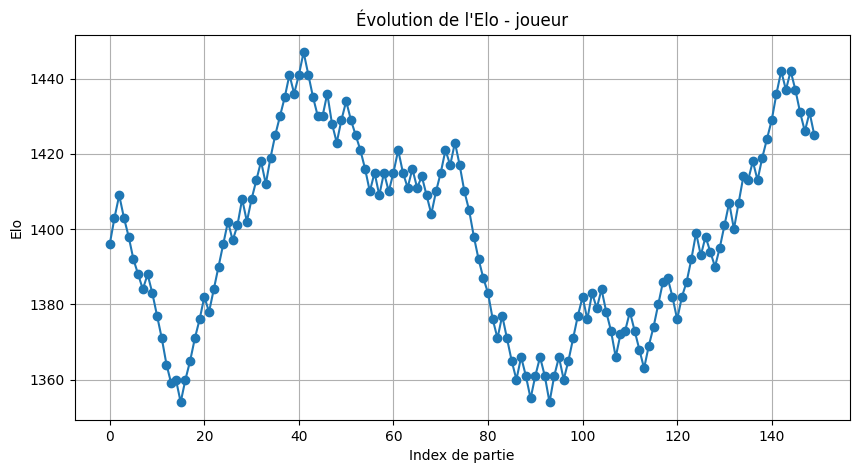

In [29]:
import matplotlib.pyplot as plt


df_plot = (
    games_final
    .sort_values(["datetime_utc", "game_id"])
    .copy()
)

df_plot["game_index"] = range(len(df_plot))

plt.figure(figsize=(10, 5))
plt.plot(df_plot["game_index"], df_plot["elo_player_after"], marker="o")
plt.xlabel("Index de partie")
plt.ylabel("Elo")
plt.title(f"Évolution de l'Elo - joueur")
plt.grid(True)
plt.show()

# 14. Dataset final

In [36]:
from src.dataset.build_final_dataset import build_final_dataset

final = build_final_dataset(games_final)

final.head()


,player_id,mean_ply_count,main_opening_white,main_opening_black,opening_diversity,opening_concentration,abandon_rate,time_loss_rate,draw_ratio,score_when_winstreak,...,weekday_bias,color_bias,session_length_performance_slope,within_session_performance_slope,games_per_day_performance_slope,games_per_week_performance_slope,elo_gain,elo_gain_per_game,elo_slope_per_game,elo_slope_per_day
0,chesstam,67.64,Queen's Pawn Game,Scandinavian Defense,2.009405,0.371977,0.286667,0.0,0.02,0.552632,...,0.09781,0.006757,0.012751,-0.120999,-0.00864,0.001358,24,0.161074,0.005033,0.4319
